## Authors
- David Robredo Manuel
- Duarte Novas Álvarez
- Rubén González Braña

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Comparison

Loading the data (results taken from `main.ipynb`)

In [2]:
metrics = {
    "model1": {"loss":0.0779, "mae":0.2068, "denormalized_mae":90961.81},
    "model2": {"loss":0.0363, "mae":0.1364, "denormalized_mae":65370.82},
    "model3": {"loss":0.0265, "mae":0.1262, "denormalized_mae":60302.55},
    "model4": {"loss":0.0513, "mae":0.1699, "denormalized_mae":89784.36},
    "model5": {"loss":0.0533, "mae":0.1767, "denormalized_mae":84363.74},
}

#### Loss Comparison

For this comparison we'll be plotting the loss values in the testing phase of the models

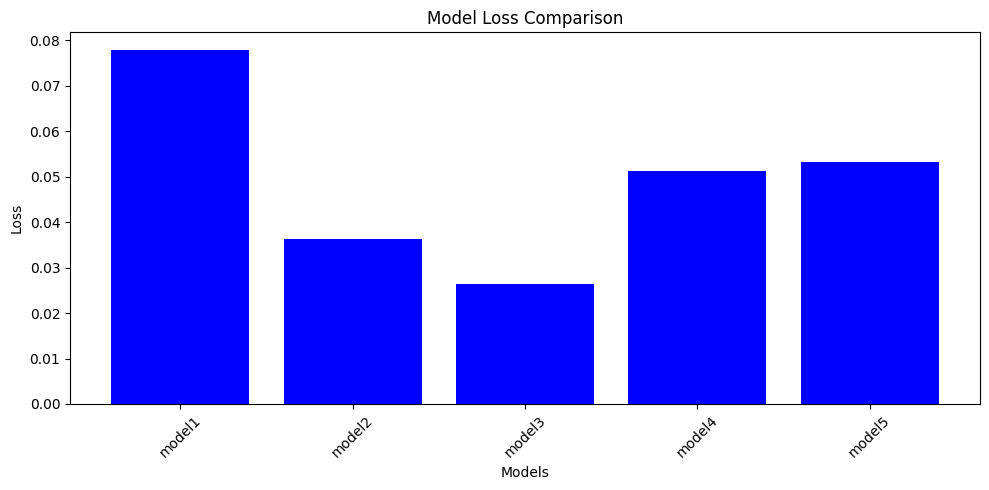

In [3]:
plt.figure(figsize=(10, 5))
plt.bar(metrics.keys(), [metrics[model]["loss"] for model in metrics.keys()], color='blue')
plt.title('Model Loss Comparison')
plt.xlabel('Models')
plt.ylabel('Loss')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As it can be seen above, the results show that model number one _(the one with two GRU layers and one simple RNN)_ has the highest loss, close to **0.078**, which indicates the worst performance among all. 

On the other hand, model number three _(the one with two GRU layers and two Dense layers)_ achieves the lowest loss, **0.0265**, making it the best-performing model in this comparison. Model two also performs relatively well with a loss of **0.0363**. Meanwhile, model four and model five show similar loss values, both slightly above **0.05**, suggesting a moderate performance.

#### MAE Comparison

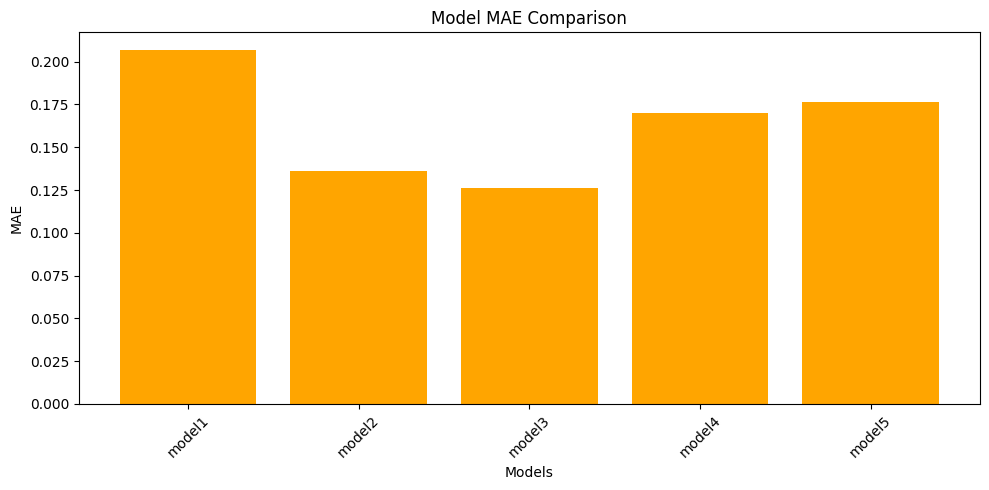

In [4]:
plt.figure(figsize=(10, 5))
plt.bar(metrics.keys(), [metrics[model]["mae"] for model in metrics.keys()], color='orange')
plt.title('Model MAE Comparison')
plt.xlabel('Models')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The models with the best performance are the third and the second model, since they have lower MAE values; while the first one presents the worst metrics. Models 4 and 5 shows intermedium values. The MAE metric is normalized. However, the values are in a relative range and it would be necessary to denormalize tham.
Next, denormalized MAE is evaluated to achieve a more practical comparison in this problem.

#### Denormalized MAE Comparison

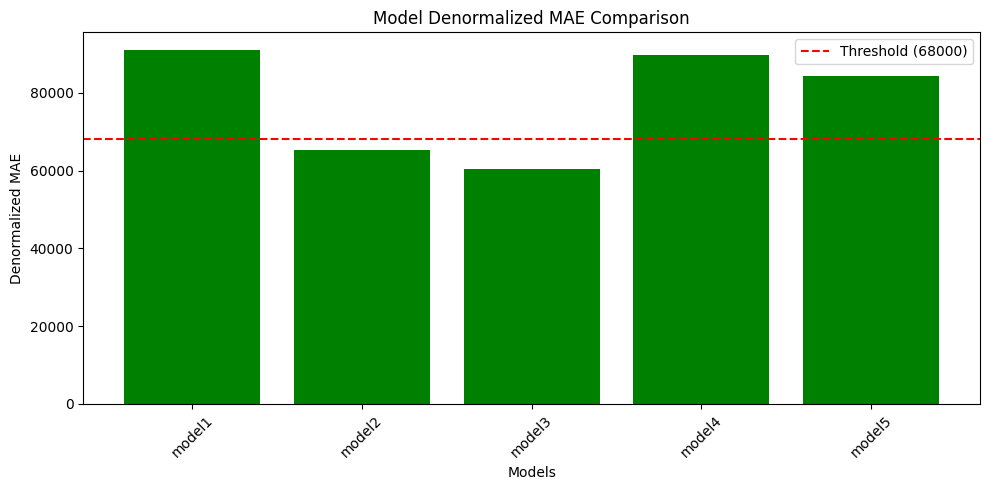

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(metrics.keys(), [metrics[model]["denormalized_mae"] for model in metrics.keys()], color='green')
plt.axhline(y=68000, color='r', linestyle='--', label='Threshold (68000)')
plt.title('Model Denormalized MAE Comparison')
plt.xlabel('Models')
plt.ylabel('Denormalized MAE')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

As it can be seen above, the results show that model number one and model number fou have the highest denormalized MAE values, both above **89,000**, which indicates a poor performance compared to the desired threshold. Model number five also exceeds the threshold, reaching around **84,363.74**. On the other hand, model number three achieves the lowest denormalized MAE, with a value of **60,302.55**, being the only model alongside model number two _(with a denormalized mae of **65,370.82**)_ that achieves a value lower that the threshold.

#### MAE & Loss Comparison

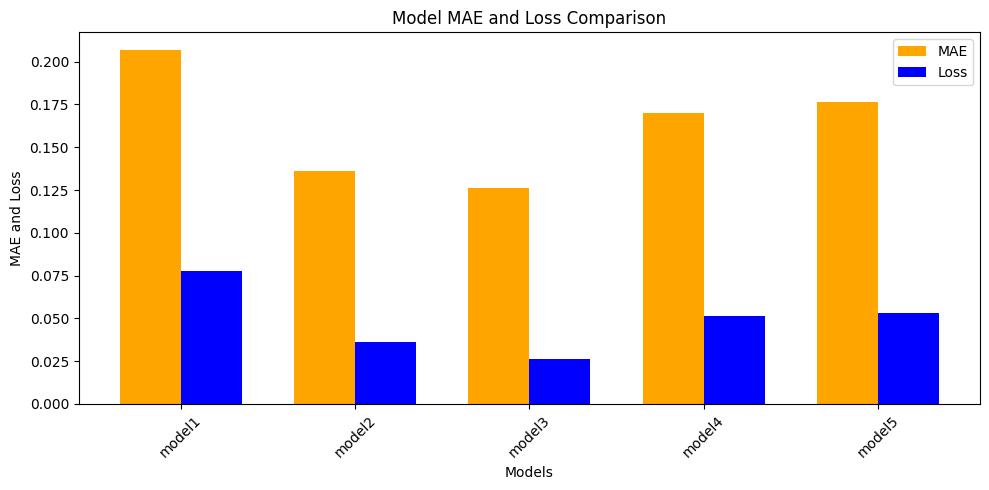

In [6]:
models = list(metrics.keys())
mae_values = [metrics[model]['mae'] for model in models]
loss_values = [metrics[model]['loss'] for model in models]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, mae_values, width, color='orange', label='MAE')
plt.bar(x + width/2, loss_values, width, color='blue', label='Loss')

plt.title('Model MAE and Loss Comparison')
plt.xlabel('Models')
plt.ylabel('MAE and Loss')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In this comparative, The normalized MAE is marked in orange, while the loss is marked in blue. Model 3 keeps being the best one, with the best MAE and loss, followed closely by the model 2. Models 4 and 5 have intermediate errors, and again, model 1 is the worst because it presents the highest error value in both metrics.
After all, with this comparison we can reinforce the ideas that we have been developing along this notebook.

#### Conclussions

In summary, after evaluating different architectures on the Walmart dataset, it is clear that the third model, with the following architecure:  

| Layer (type) | Output Shape | Param # |
|-------------|--------------|:-------:|
| gru_4 (GRU) | (None, 12, 128) | 52,224 |
| gru_5 (GRU) | (None, 64) | 37,248 |
| dense_3 (Dense) | (None, 32) | 2,080 |
| dense_4 (Dense) | (None, 16) | 528 |
| dense_5 (Dense) | (None, 1) | 17 |



achieved the best performance with the lowest denormalized MAE of **60,302.55**. This result not only surpassed the established threshold of 68,000 but also demonstrated the effectiveness of incorporating additional dense layers after the recurrent blocks. 

The second model, with the following architecture:

| Layer (type) | Output Shape | Param # |
|-------------|--------------|:-------:|
| gru (GRU) | (None, 12, 128) | 52,224 |
| lstm (LSTM) | (None, 12, 16) | 9,280 |
| gru_1 (GRU) | (None, 16) | 1,632 |
| dense (Dense) | (None, 1) | 17 |


 also performed adequately, maintaining an MAE under the threshold.

From this results we can conclude a series of facts:
- In this problem, the use of SimpleRNN layers have only worsen the models' performance (observable in models 1 and 5).
- Not always a higher number of neurons cause a better performance (although Model 4 has the same architecture as Model 2 but with more neurones, Model 2's performance is better).
- The addition of extra Dense layers seems to cause an improvement in performance.
- Normalizing data helps achieving better results than working with the raw data, this also causes the model to emit a normalized MAE, which has to be denormalized for better understanding.
